<a href="https://colab.research.google.com/github/dilek-gokalp/dilek-gokalp/blob/main/Social_Media_User_Behavior.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("social_media_user_behavior.csv")

df.head()

,user_id,age,gender,country,profession,primary_platform,platforms_used_count,daily_usage_hours,sessions_per_day,avg_session_duration_min,preferred_device,peak_usage_time,followers_count,following_count,posts_per_week,likes_given_per_day,comments_per_day,shares_per_day,dms_sent_per_day,preferred_content_type,scroll_speed,ad_click_rate,purchased_via_social_media,monthly_spend_via_social_usd,primary_purpose,sleep_disruption,self_reported_mental_health_score,screen_time_concern,notification_frequency,privacy_setting,influencer_status,account_join_date,mood_while_scrolling,takes_social_media_breaks
0,USR00001,30,Female,UK,Doctor,Facebook,1,1.6,2,48.0,Smartphone,Late Night (12am+),353,99,1,17,1,3,8,Photos,Medium,0.089,Yes,67.72,Entertainment,No impact,3.9,No,Do Not Disturb,Friends Only,No,2022-10-21,Neutral,No
1,USR00002,25,Male,USA,Entrepreneur,Instagram,2,2.4,5,28.8,Smartphone,Afternoon (12-4pm),276,514,2,28,3,4,16,Memes,Medium,0.065,Yes,1.62,News & Updates,Moderate impact,4.2,No,Selected,Public,No,2024-12-03,Neutral,Yes
2,USR00003,32,Male,UAE,Freelancer,TikTok,5,0.5,6,5.0,Smartphone,Night (9pm-12am),203,422,3,26,4,2,7,Videos,Slow,0.278,No,0.00,Learning,Mild impact,4.8,Yes,Always On,Friends Only,No,2023-03-29,Happy,Yes
3,USR00004,39,Prefer not to say,Pakistan,Other,TikTok,4,3.0,7,25.7,Smartphone,Evening (6-9pm),29083,474,1,16,3,1,12,Entertainment,Fast,0.094,No,0.00,Entertainment,Mild impact,7.9,Somewhat,Always On,Public,Yes,2024-04-26,Happy,No
4,USR00005,25,Male,UK,Other,YouTube,3,3.9,7,33.4,Tablet,Evening (6-9pm),104,197,2,27,7,4,7,Photos,Fast,0.075,No,0.00,Entertainment,Mild impact,6.5,No,Do Not Disturb,Public,No,2023-09-08,Inspired,No


In [ ]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (2000, 34)

Column names:
['user_id', 'age', 'gender', 'country', 'profession', 'primary_platform', 'platforms_used_count', 'daily_usage_hours', 'sessions_per_day', 'avg_session_duration_min', 'preferred_device', 'peak_usage_time', 'followers_count', 'following_count', 'posts_per_week', 'likes_given_per_day', 'comments_per_day', 'shares_per_day', 'dms_sent_per_day', 'preferred_content_type', 'scroll_speed', 'ad_click_rate', 'purchased_via_social_media', 'monthly_spend_via_social_usd', 'primary_purpose', 'sleep_disruption', 'self_reported_mental_health_score', 'screen_time_concern', 'notification_frequency', 'privacy_setting', 'influencer_status', 'account_join_date', 'mood_while_scrolling', 'takes_social_media_breaks']

Data types:
user_id                               object
age                                    int64
gender                                object
country                               object
profession                            object
primary_platform  

,user_id,age,gender,country,profession,primary_platform,platforms_used_count,daily_usage_hours,sessions_per_day,avg_session_duration_min,preferred_device,peak_usage_time,followers_count,following_count,posts_per_week,likes_given_per_day,comments_per_day,shares_per_day,dms_sent_per_day,preferred_content_type,scroll_speed,ad_click_rate,purchased_via_social_media,monthly_spend_via_social_usd,primary_purpose,sleep_disruption,self_reported_mental_health_score,screen_time_concern,notification_frequency,privacy_setting,influencer_status,account_join_date,mood_while_scrolling,takes_social_media_breaks
0,USR00001,30,Female,UK,Doctor,Facebook,1,1.6,2,48.0,Smartphone,Late Night (12am+),353,99,1,17,1,3,8,Photos,Medium,0.089,Yes,67.72,Entertainment,No impact,3.9,No,Do Not Disturb,Friends Only,No,2022-10-21,Neutral,No
1,USR00002,25,Male,USA,Entrepreneur,Instagram,2,2.4,5,28.8,Smartphone,Afternoon (12-4pm),276,514,2,28,3,4,16,Memes,Medium,0.065,Yes,1.62,News & Updates,Moderate impact,4.2,No,Selected,Public,No,2024-12-03,Neutral,Yes
2,USR00003,32,Male,UAE,Freelancer,TikTok,5,0.5,6,5.0,Smartphone,Night (9pm-12am),203,422,3,26,4,2,7,Videos,Slow,0.278,No,0.00,Learning,Mild impact,4.8,Yes,Always On,Friends Only,No,2023-03-29,Happy,Yes
3,USR00004,39,Prefer not to say,Pakistan,Other,TikTok,4,3.0,7,25.7,Smartphone,Evening (6-9pm),29083,474,1,16,3,1,12,Entertainment,Fast,0.094,No,0.00,Entertainment,Mild impact,7.9,Somewhat,Always On,Public,Yes,2024-04-26,Happy,No
4,USR00005,25,Male,UK,Other,YouTube,3,3.9,7,33.4,Tablet,Evening (6-9pm),104,197,2,27,7,4,7,Photos,Fast,0.075,No,0.00,Entertainment,Mild impact,6.5,No,Do Not Disturb,Public,No,2023-09-08,Inspired,No


In [ ]:
missing_values = df.isnull().sum()
duplicate_rows = df.duplicated().sum()

print("Missing values per column:")
print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())
print("Duplicate rows:", duplicate_rows)

Missing values per column:
user_id                              0
age                                  0
gender                               0
country                              0
profession                           0
primary_platform                     0
platforms_used_count                 0
daily_usage_hours                    0
sessions_per_day                     0
avg_session_duration_min             0
preferred_device                     0
peak_usage_time                      0
followers_count                      0
following_count                      0
posts_per_week                       0
likes_given_per_day                  0
comments_per_day                     0
shares_per_day                       0
dms_sent_per_day                     0
preferred_content_type               0
scroll_speed                         0
ad_click_rate                        0
purchased_via_social_media           0
monthly_spend_via_social_usd         0
primary_purpose                      

In [ ]:
df["account_join_date"] = pd.to_datetime(df["account_join_date"], errors="coerce")

df["account_age_days"] = (pd.Timestamp.today() - df["account_join_date"]).dt.days

df[["account_join_date", "account_age_days"]].head()

,account_join_date,account_age_days
0,2022-10-21,1329
1,2024-12-03,555
2,2023-03-29,1170
3,2024-04-26,776
4,2023-09-08,1007


In [ ]:
numeric_cols = [
    "age",
    "platforms_used_count",
    "daily_usage_hours",
    "sessions_per_day",
    "avg_session_duration_min",
    "followers_count",
    "following_count",
    "posts_per_week",
    "likes_given_per_day",
    "comments_per_day",
    "shares_per_day",
    "dms_sent_per_day",
    "ad_click_rate",
    "monthly_spend_via_social_usd",
    "self_reported_mental_health_score",
    "account_age_days"
]

df_numeric = df[numeric_cols]

df_numeric.head()

,age,platforms_used_count,daily_usage_hours,sessions_per_day,avg_session_duration_min,followers_count,following_count,posts_per_week,likes_given_per_day,comments_per_day,shares_per_day,dms_sent_per_day,ad_click_rate,monthly_spend_via_social_usd,self_reported_mental_health_score,account_age_days
0,30,1,1.6,2,48.0,353,99,1,17,1,3,8,0.089,67.72,3.9,1329
1,25,2,2.4,5,28.8,276,514,2,28,3,4,16,0.065,1.62,4.2,555
2,32,5,0.5,6,5.0,203,422,3,26,4,2,7,0.278,0.00,4.8,1170
3,39,4,3.0,7,25.7,29083,474,1,16,3,1,12,0.094,0.00,7.9,776
4,25,3,3.9,7,33.4,104,197,2,27,7,4,7,0.075,0.00,6.5,1007


In [ ]:
summary_stats = df_numeric.describe().T
summary_stats

,count,mean,std,min,25%,50%,75%,max
age,2000.0,26.986000,7.649775,13.000,22.00000,27.000,32.0000,57.000
platforms_used_count,2000.0,3.010000,1.431756,1.000,2.00000,3.000,4.0000,5.000
daily_usage_hours,2000.0,2.990650,1.858501,0.500,1.60000,2.600,3.9000,12.000
sessions_per_day,2000.0,5.024500,2.249985,1.000,3.00000,5.000,6.0000,15.000
avg_session_duration_min,2000.0,47.547400,51.104393,3.300,18.97500,34.000,56.0000,594.000
followers_count,2000.0,4153.737500,47935.625651,0.000,201.75000,688.000,2320.5000,2110323.000
following_count,2000.0,513.998500,851.817900,4.000,109.00000,249.000,580.0000,10000.000
posts_per_week,2000.0,2.964000,1.679915,0.000,2.00000,3.000,4.0000,10.000
likes_given_per_day,2000.0,19.883000,4.389527,6.000,17.00000,20.000,23.0000,38.000
comments_per_day,2000.0,3.991500,1.997354,0.000,3.00000,4.000,5.0000,11.000


In [ ]:
categorical_cols = [
    "gender",
    "country",
    "profession",
    "primary_platform",
    "preferred_device",
    "peak_usage_time",
    "preferred_content_type",
    "primary_purpose",
    "sleep_disruption",
    "screen_time_concern",
    "notification_frequency",
    "privacy_setting",
    "influencer_status",
    "mood_while_scrolling",
    "takes_social_media_breaks"
]

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


gender
gender
Female               971
Male                 922
Non-binary            66
Prefer not to say     41
Name: count, dtype: int64

country
country
Pakistan     369
India        323
USA          314
UAE          182
UK           179
Canada       163
Australia    144
Germany      138
Nigeria       97
Brazil        91
Name: count, dtype: int64

profession
profession
Engineer        224
Marketer        213
Teacher         213
Other           209
Researcher      207
Entrepreneur    201
Student         197
Freelancer      190
Doctor          180
Designer        166
Name: count, dtype: int64

primary_platform
primary_platform
Instagram    415
TikTok       395
Twitter/X    316
Facebook     270
YouTube      250
Snapchat     158
LinkedIn     110
Pinterest     86
Name: count, dtype: int64

preferred_device
preferred_device
Smartphone    1316
Laptop         354
Tablet         159
Desktop        112
Smart TV        59
Name: count, dtype: int64

peak_usage_time
peak_usage_time
Evening (6-

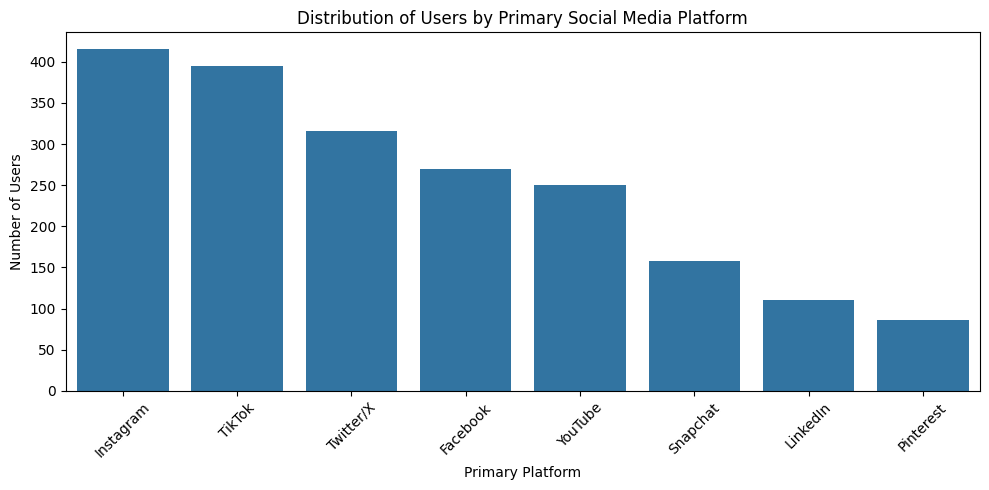

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="primary_platform", order=df["primary_platform"].value_counts().index)
plt.title("Distribution of Users by Primary Social Media Platform")
plt.xlabel("Primary Platform")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

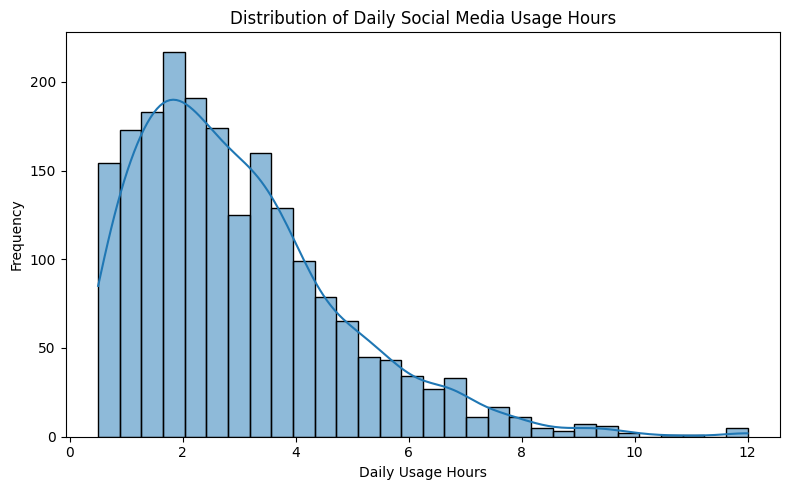

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df["daily_usage_hours"], bins=30, kde=True)
plt.title("Distribution of Daily Social Media Usage Hours")
plt.xlabel("Daily Usage Hours")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

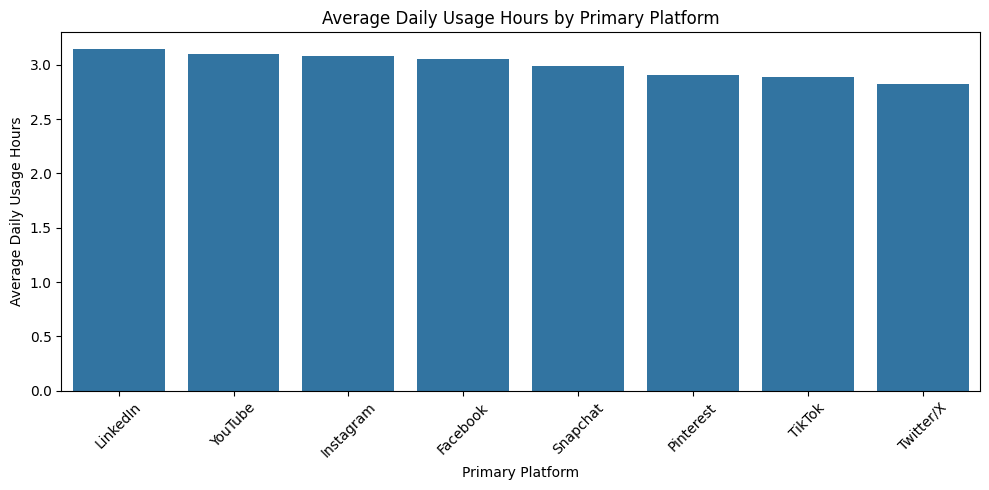

In [ ]:
platform_usage = df.groupby("primary_platform")["daily_usage_hours"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=platform_usage.index, y=platform_usage.values)
plt.title("Average Daily Usage Hours by Primary Platform")
plt.xlabel("Primary Platform")
plt.ylabel("Average Daily Usage Hours")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

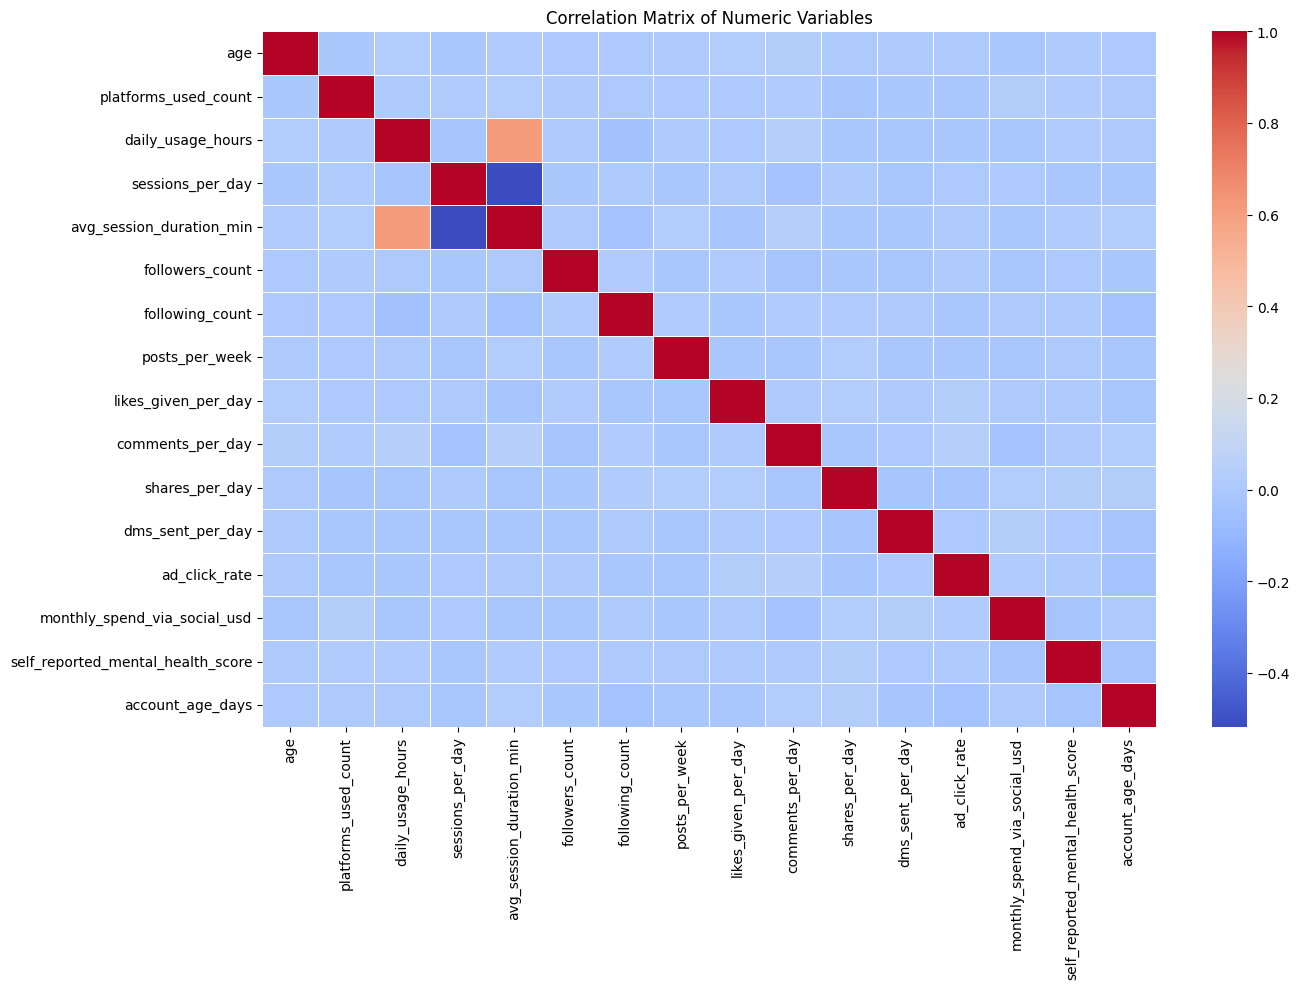

In [ ]:
plt.figure(figsize=(14, 10))
corr_matrix = df_numeric.corr()

sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of Numeric Variables")
plt.tight_layout()
plt.show()

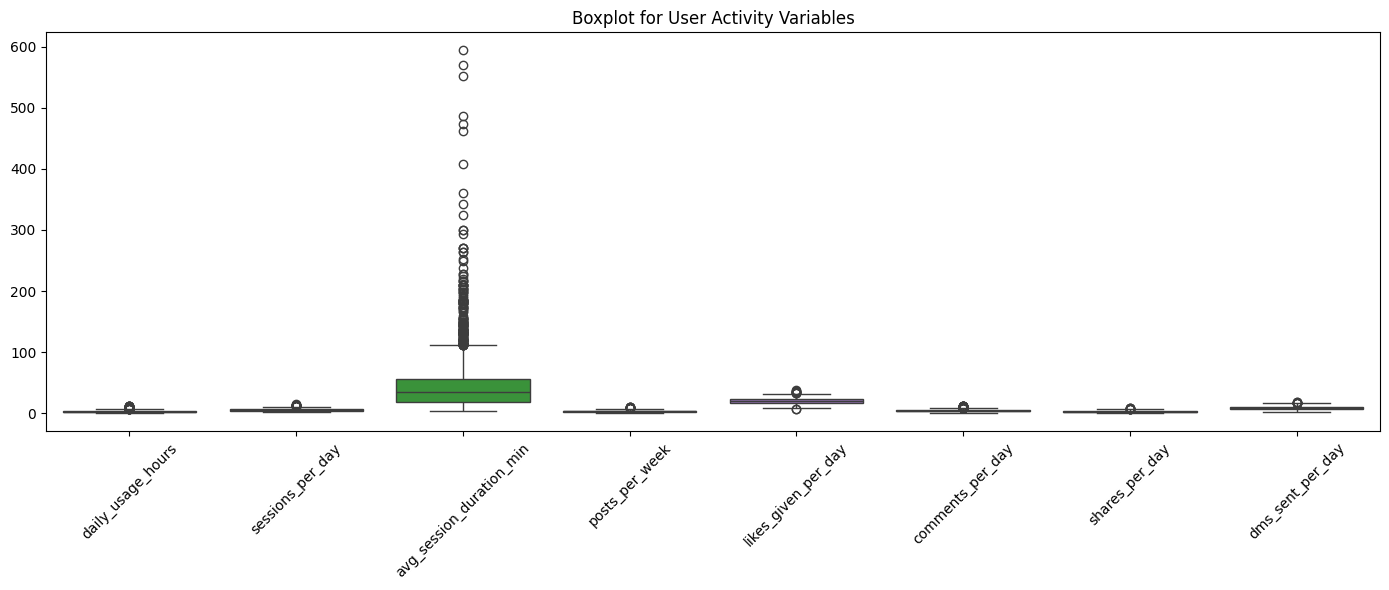

In [ ]:
selected_boxplot_cols = [
    "daily_usage_hours",
    "sessions_per_day",
    "avg_session_duration_min",
    "posts_per_week",
    "likes_given_per_day",
    "comments_per_day",
    "shares_per_day",
    "dms_sent_per_day"
]

plt.figure(figsize=(14, 6))
sns.boxplot(data=df[selected_boxplot_cols])
plt.title("Boxplot for User Activity Variables")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
cluster_features = [
    "daily_usage_hours",
    "sessions_per_day",
    "avg_session_duration_min",
    "posts_per_week",
    "likes_given_per_day",
    "comments_per_day",
    "shares_per_day",
    "dms_sent_per_day",
    "followers_count",
    "following_count"
]

X = df[cluster_features]

X.head()

,daily_usage_hours,sessions_per_day,avg_session_duration_min,posts_per_week,likes_given_per_day,comments_per_day,shares_per_day,dms_sent_per_day,followers_count,following_count
0,1.6,2,48.0,1,17,1,3,8,353,99
1,2.4,5,28.8,2,28,3,4,16,276,514
2,0.5,6,5.0,3,26,4,2,7,203,422
3,3.0,7,25.7,1,16,3,1,12,29083,474
4,3.9,7,33.4,2,27,7,4,7,104,197


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-7.48451612e-01, -1.34456757e+00,  8.85859640e-03,
        -1.16939902e+00, -6.56954882e-01, -1.49810617e+00,
         7.15709646e-01, -9.36772786e-03, -7.93081970e-02,
        -4.87313414e-01],
       [-3.17889437e-01, -1.08916864e-02, -3.66936920e-01,
        -5.73982005e-01,  1.84963676e+00, -4.96530928e-01,
         1.42328221e+00,  2.87301008e+00, -8.09149197e-02,
         1.76138015e-06],
       [-1.34047460e+00,  4.33666942e-01, -8.32766779e-01,
         2.14350126e-02,  1.39389283e+00,  4.25669479e-03,
         8.13708446e-03, -3.69664953e-01, -8.24381762e-02,
        -1.08029555e-01],
       [ 5.03219543e-03,  8.78225570e-01, -4.27612238e-01,
        -1.16939902e+00, -8.84826850e-01, -4.96530928e-01,
        -6.99435477e-01,  1.43182117e+00,  5.20187164e-01,
        -4.69683760e-02],
       [ 4.89414643e-01,  8.78225570e-01, -2.76902578e-01,
        -5.73982005e-01,  1.62176479e+00,  1.50661956e+00,
         1.42328221e+00, -3.69664953e-01, -8.45039625e-02,
        -3.

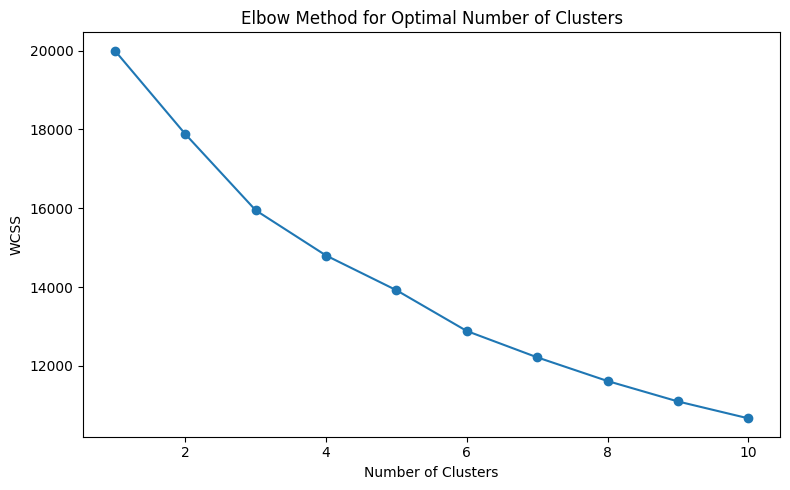

In [ ]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.tight_layout()
plt.show()

In [ ]:
silhouette_scores = {}

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score

silhouette_scores

{2: np.float64(0.16409265094973152),
 3: np.float64(0.15652185707808797),
 4: np.float64(0.1044239604217072),
 5: np.float64(0.09396035897248711),
 6: np.float64(0.0973680417465142),
 7: np.float64(0.09679898165959415),
 8: np.float64(0.0969573191963978),
 9: np.float64(0.10098146865683603),
 10: np.float64(0.1026099120945299)}

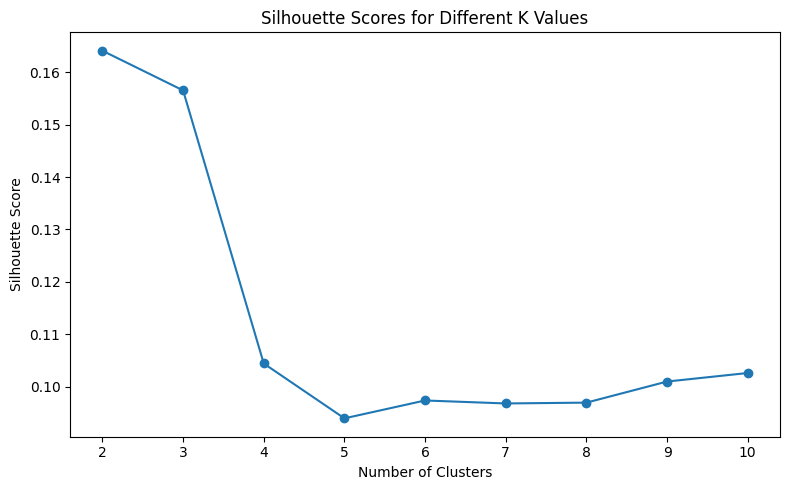

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker="o")
plt.title("Silhouette Scores for Different K Values")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

df["kmeans_cluster"].value_counts()

,count
kmeans_cluster,
0,1510
1,490


In [ ]:
kmeans_profile = df.groupby("kmeans_cluster")[cluster_features].mean().round(2)

kmeans_profile

,daily_usage_hours,sessions_per_day,avg_session_duration_min,posts_per_week,likes_given_per_day,comments_per_day,shares_per_day,dms_sent_per_day,followers_count,following_count
kmeans_cluster,,,,,,,,,,
0,2.30,5.52,27.72,2.92,19.93,3.86,2.00,8.07,3018.90,540.74
1,5.11,3.49,108.64,3.09,19.74,4.40,1.94,7.89,7650.89,431.60


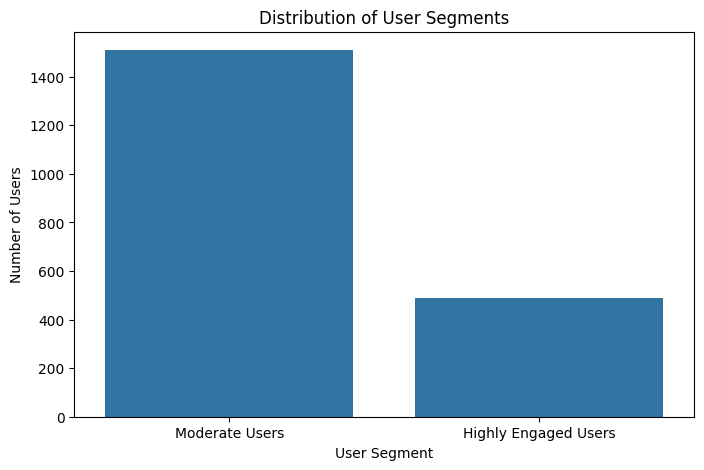

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="user_segment"
)

plt.title("Distribution of User Segments")
plt.xlabel("User Segment")
plt.ylabel("Number of Users")

plt.show()

In [ ]:
segment_summary = df.groupby("user_segment")[[
    "daily_usage_hours",
    "avg_session_duration_min",
    "posts_per_week",
    "likes_given_per_day",
    "comments_per_day"
]].mean().round(2)

segment_summary

,daily_usage_hours,avg_session_duration_min,posts_per_week,likes_given_per_day,comments_per_day
user_segment,,,,,
Highly Engaged Users,5.11,108.64,3.09,19.74,4.40
Moderate Users,2.30,27.72,2.92,19.93,3.86


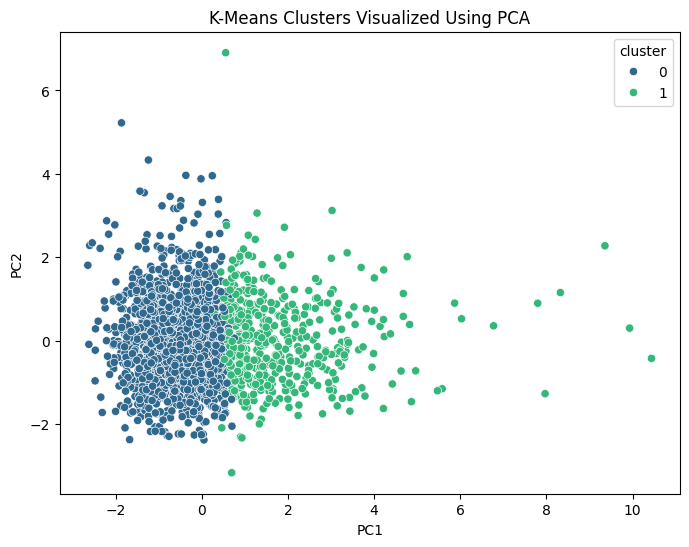

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["cluster"] = df["kmeans_cluster"]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="viridis"
)

plt.title("K-Means Clusters Visualized Using PCA")
plt.show()

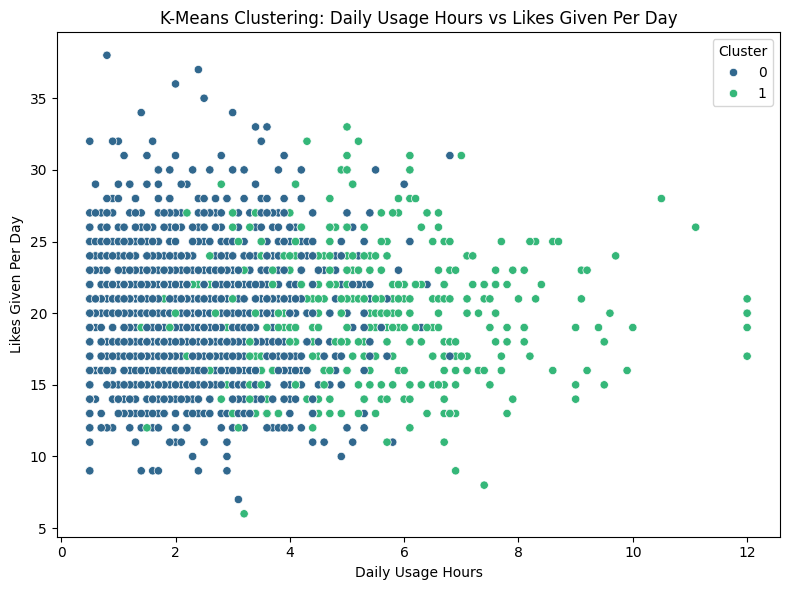

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="daily_usage_hours",
    y="likes_given_per_day",
    hue="kmeans_cluster",
    palette="viridis"
)
plt.title("K-Means Clustering: Daily Usage Hours vs Likes Given Per Day")
plt.xlabel("Daily Usage Hours")
plt.ylabel("Likes Given Per Day")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

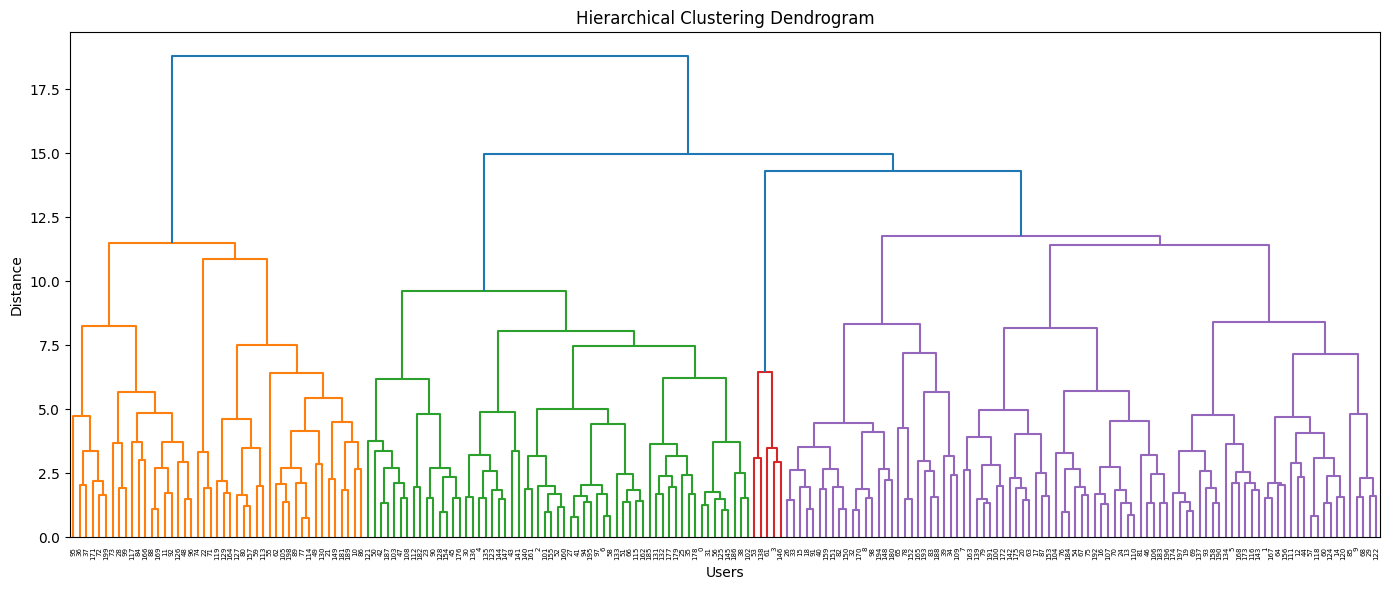

In [ ]:
sample_X = pd.DataFrame(X_scaled, columns=cluster_features).sample(n=200, random_state=42)

linked = linkage(sample_X, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Users")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [ ]:
hierarchical = AgglomerativeClustering(n_clusters=3, linkage="ward")
df["hierarchical_cluster"] = hierarchical.fit_predict(X_scaled)

df["hierarchical_cluster"].value_counts()

,count
hierarchical_cluster,
0,1663
2,336
1,1


In [ ]:
hierarchical_profile = df.groupby("hierarchical_cluster")[cluster_features].mean().round(2)

hierarchical_profile

,daily_usage_hours,sessions_per_day,avg_session_duration_min,posts_per_week,likes_given_per_day,comments_per_day,shares_per_day,dms_sent_per_day,followers_count,following_count
hierarchical_cluster,,,,,,,,,,
0,2.49,5.29,33.10,2.97,20.02,4.00,2.09,8.11,2939.87,533.44
1,3.50,4.00,52.50,2.00,23.00,2.00,2.00,6.00,2110323.00,1219.00
2,5.47,3.70,119.02,2.92,19.19,3.94,1.47,7.64,3893.29,415.65


In [ ]:
kmeans_silhouette = silhouette_score(X_scaled, df["kmeans_cluster"])
kmeans_db = davies_bouldin_score(X_scaled, df["kmeans_cluster"])

hierarchical_silhouette = silhouette_score(X_scaled, df["hierarchical_cluster"])
hierarchical_db = davies_bouldin_score(X_scaled, df["hierarchical_cluster"])

evaluation_table = pd.DataFrame({
    "Model": ["K-Means", "Hierarchical Clustering"],
    "Silhouette Score": [kmeans_silhouette, hierarchical_silhouette],
    "Davies-Bouldin Index": [kmeans_db, hierarchical_db]
})

evaluation_table

,Model,Silhouette Score,Davies-Bouldin Index
0,K-Means,0.164093,2.301092
1,Hierarchical Clustering,0.155782,1.485278


In [ ]:
kmeans_profile

,daily_usage_hours,sessions_per_day,avg_session_duration_min,posts_per_week,likes_given_per_day,comments_per_day,shares_per_day,dms_sent_per_day,followers_count,following_count
kmeans_cluster,,,,,,,,,,
0,2.30,5.52,27.72,2.92,19.93,3.86,2.00,8.07,3018.90,540.74
1,5.11,3.49,108.64,3.09,19.74,4.40,1.94,7.89,7650.89,431.60


In [ ]:
cluster_names = {
    0: "Moderate Users",
    1: "Highly Engaged Users",
    2: "Low Engagement Users"
}

df["user_segment"] = df["kmeans_cluster"].map(cluster_names)

df[["kmeans_cluster", "user_segment"]].head()

,kmeans_cluster,user_segment
0,0,Moderate Users
1,0,Moderate Users
2,0,Moderate Users
3,0,Moderate Users
4,0,Moderate Users
